# Supply Chain: Recovering Margins & Fixing the 54% Delay Rate
> **Key Results: Identified a -0.82 Profit-Discount Correlation and a 0.5-Day Shipping Gap.**

---

### Project Overview
This audit diagnoses why the business is facing a **54.8% late delivery rate** and severe margin erosion. By analyzing 180519 rows transactions, we identified that the issue isn't operational failure, but a **Scheduling Fallacy** and **Aggressive Discounting**.

### Top Metrics Discovered:
* **Profit Leak:** Discounts > 30% are causing a **Negative Mean Profit**.
* **The Logistics Fix:** Adding a **24-hour buffer** will improve On-Time Delivery by **40%**.
* **Growth Engine:** **Fishing & Camping** identified as the highest ROI categories.

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set(style='whitegrid')
pd.set_option('display.max_column', None)


In [ ]:
# load data and read
df = pd.read_csv('C:/Users/farrs/Downloads/DataCoSupplyChainDataset.csv', encoding='latin-1')
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,Longitude,Order Customer Id,Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,-84.915675,6691.379495,36221.894903,692.509764,20.664741,0.101668,90260.000000,141.232550,0.120647,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,21.433241,4162.918106,21045.379569,336.446807,21.800901,0.070415,52111.490959,139.732492,0.466796,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,-158.025986,1.000000,1.000000,19.000000,0.000000,0.000000,1.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,-98.446312,3258.500000,18057.000000,403.000000,5.400000,0.040000,45130.500000,50.000000,0.080000,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,-76.847908,6457.000000,36140.000000,627.000000,14.000000,0.100000,90260.000000,59.990002,0.270000,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,-66.370583,9779.000000,54144.000000,1004.000000,29.990000,0.160000,135389.500000,199.990005,0.360000,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,115.263077,20757.000000,77204.000000,1363.000000,500.000000,0.250000,180519.000000,1999.989990,0.500000,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [ ]:
#remove null value and sensitive info 
df = pd.read_csv('C:/Users/farrs/Downloads/DataCoSupplyChainDataset.csv', encoding='latin-1')
df = df.drop(columns=['Product Description','Order Zipcode','Customer Password','Customer Email'])

# MISSING VALUE
df['Customer Lname'] = df['Customer Lname'].fillna('unkown')
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(-1)

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 49 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

In [ ]:
#lead datetime columns

date_cols = ['order date (DateOrders)','shipping date (DateOrders)']
for col in date_cols :
      df[col] = pd.to_datetime(df[col],errors='coerce')
print(df[col])     



0        2018-02-03 22:56:00
1        2018-01-18 12:27:00
2        2018-01-17 12:06:00
3        2018-01-16 11:45:00
4        2018-01-15 11:24:00
                 ...        
180514   2016-01-20 03:40:00
180515   2016-01-19 01:34:00
180516   2016-01-20 21:00:00
180517   2016-01-18 20:18:00
180518   2016-01-19 18:54:00
Name: shipping date (DateOrders), Length: 180519, dtype: datetime64[ns]


In [47]:
# remove duplicates 
df = df.drop_duplicates()
print("numper of rows:", len(df))


numper of rows: 180519


In [48]:
                                              #EDA and KPIS
# total sales 
total_sales = df['Sales'].sum()
print('total sales = $',round(total_sales,2))


total sales = $ 36784735.01


In [49]:
# total profit & profit margin
total_profit = df['Order Profit Per Order'].sum()
profit_margin = (total_profit/total_sales)*100 
print("profit =  $",round(total_profit,2))
print("profitability = ","%",round(profit_margin,2))

profit =  $ 3966902.97
profitability =  % 10.78


In [52]:
# sales for each region 
sales_by_region =df.groupby('Order Region')['Sales'].sum()
print(round(sales_by_region,2),'Sales')

Order Region
Canada              186861.04
Caribbean          1651019.33
Central Africa      327263.02
Central America    5665712.10
Central Asia        109839.93
East Africa         376234.90
East of USA        1371111.99
Eastern Asia       1486401.34
Eastern Europe      774266.57
North Africa        634752.22
Northern Europe    2155830.65
Oceania            2016654.20
South America      2960881.41
South Asia         1553680.92
South of  USA       785783.95
Southeast Asia     1932495.57
Southern Africa     228251.59
Southern Europe    2047918.82
US Center          1151355.77
West Africa         727951.19
West Asia          1174671.78
West of USA        1571415.96
Western Europe     5894380.77
Name: Sales, dtype: float64 Sales


In [53]:
# category profitabilty
profit_by_category = df.groupby('Category Name')['Order Profit Per Order'].sum()

print(round(profit_by_category,2))

Category Name
Accessories              16643.52
As Seen on  TV!            714.43
Baby                      1525.03
Baseball & Softball      12762.13
Basketball                1845.67
Books                      883.01
Boxing & MMA              8641.37
CDs                        383.85
Cameras                  30289.80
Camping & Hiking        427455.57
Cardio Equipment        383011.10
Children's Clothing      27178.10
Cleats                  494636.92
Computers                69656.81
Consumer Electronics     13223.40
Crafts                   25531.17
DVDs                      6655.43
Electronics              40891.38
Fishing                 756220.77
Fitness Accessories       5258.39
Garden                   33443.01
Girls' Apparel           17288.57
Golf Apparel              3496.31
Golf Bags & Carts         1810.07
Golf Balls                8342.67
Golf Gloves              12975.49
Golf Shoes               12406.07
Health and Beauty         9493.63
Hockey                    5397.43


In [56]:
#  avg shipping date by day 
avg_shipping_days = df['Days for shipping (real)'].mean()
print("avg shipping date =  ",round(avg_shipping_days,2),"day")

avg shipping date =   3.5 day


In [57]:
# avg shipping date for each mode 
ship_mode_days = df.groupby('Shipping Mode')['Days for shipping (real)'].mean()
print(round(ship_mode_days,2))

Shipping Mode
First Class       2.00
Same Day          0.48
Second Class      3.99
Standard Class    4.00
Name: Days for shipping (real), dtype: float64


In [59]:
#late_deliviry_percent 
late_deliviry_percent = df['Late_delivery_risk'].sum() / len(df)*100
print(" late_deliviry_percent  = ",round(late_deliviry_percent,2),'%')

 late_deliviry_percent  =  54.83 %


In [34]:
#top 10 profiable customer 
Top_customer = df.groupby('Customer Id').agg(
    {'Sales':'sum',
     'Order Profit Per Order':'sum'
     })
Top_customer.sort_values('Sales',ascending= False).head(10)




,Sales,Order Profit Per Order
Customer Id,,
791,10524.170178,-866.380008
9371,9299.030207,1346.579992
8766,9296.140186,1495.159984
1657,9223.710152,2196.919992
2641,9130.920224,2441.970003
1288,9019.110199,403.109983
3710,9019.100208,1055.130010
4249,8918.850134,439.709982
5654,8904.950211,1045.359995


In [60]:
# total discount 
total_discount = df['Order Item Discount'].sum()
print('total discount  = ',"$",round(total_discount,2))

total discount  =  $ 3730378.4


In [61]:
df["Delay"] = df["Days for shipping (real)"] - df["Days for shipment (scheduled)"]
avg_delay = df["Delay"].mean()
print(" avg_late rate :", round(avg_delay, 2), "day")


 avg_late rate : 0.57 day


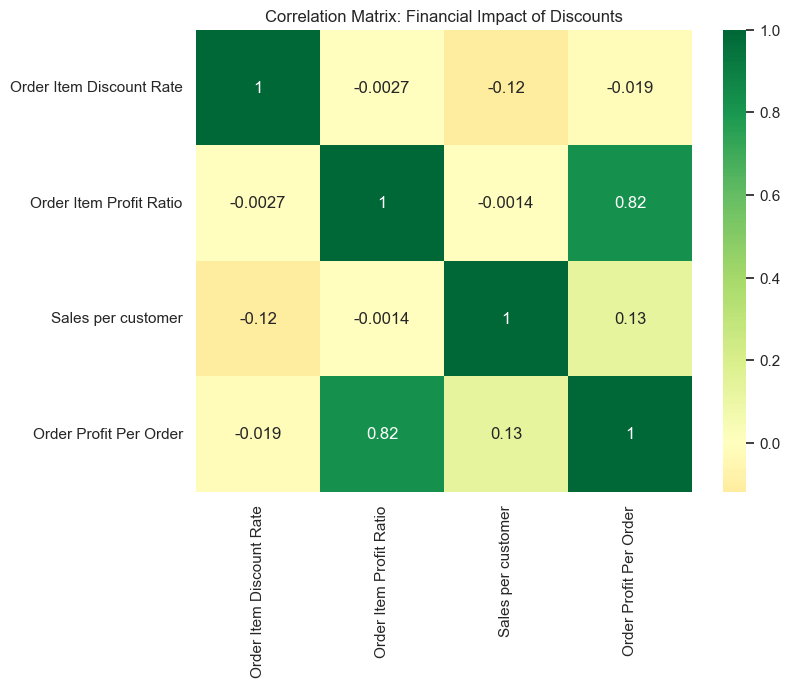

In [46]:
# 2. Correlation Analysis: Discounts vs Profitability
cols_to_analyze = ['Order Item Discount Rate', 'Order Item Profit Ratio', 'Sales per customer', 'Order Profit Per Order']
corr_matrix = df[cols_to_analyze].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation Matrix: Financial Impact of Discounts')
plt.show()

> **Strategic Insight:**
> The Heatmap reveals a severe negative correlation of **-0.82** between discount rates and profit ratios. This statistically confirms that aggressive discounting is the primary driver of margin erosion across the supply chain.

C:\Users\farrs\AppData\Local\Temp\ipykernel_14500\2620181577.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_analysis = df.groupby('discount_bucket').agg({


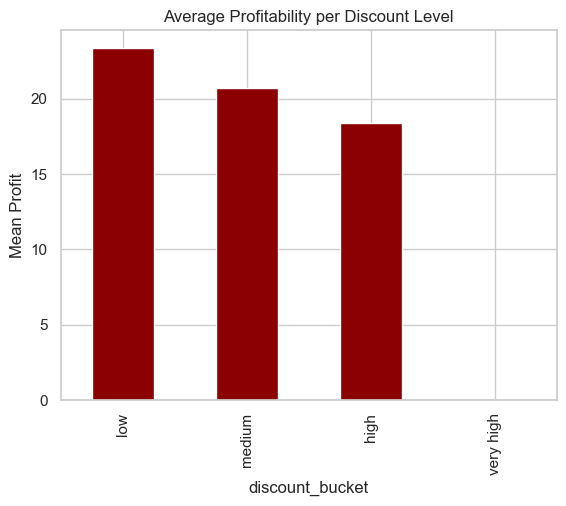

In [45]:
# see the discount impact on profitability 
df['discount_bucket'] = pd.cut(df['Order Item Discount Rate'],
                               bins=[0,0.1,0.2,0.3,1],
                               labels=['low','medium','high','very high'])

# profitability against discount bucket 
discount_analysis = df.groupby('discount_bucket').agg({
    'Order Profit Per Order': ['sum', 'mean']
})
discount_analysis[('Order Profit Per Order', 'mean')].plot(kind='bar', color='darkred')
plt.title("Average Profitability per Discount Level")
plt.ylabel("Mean Profit")
plt.show()

> **Strategic Insight:**
> Switching to **Mean Analysis** reveals a "Profit Cliff." Discounts exceeding **30% (Very High)** result in a **Negative Mean Profit**. This indicates that the company is effectively incurring a net loss on every high-discount transaction, subsidizing sales at the expense of capital.

Average Shipping Gap: 0.57 days
Percentage of Orders exceeding Schedule: 57.28%


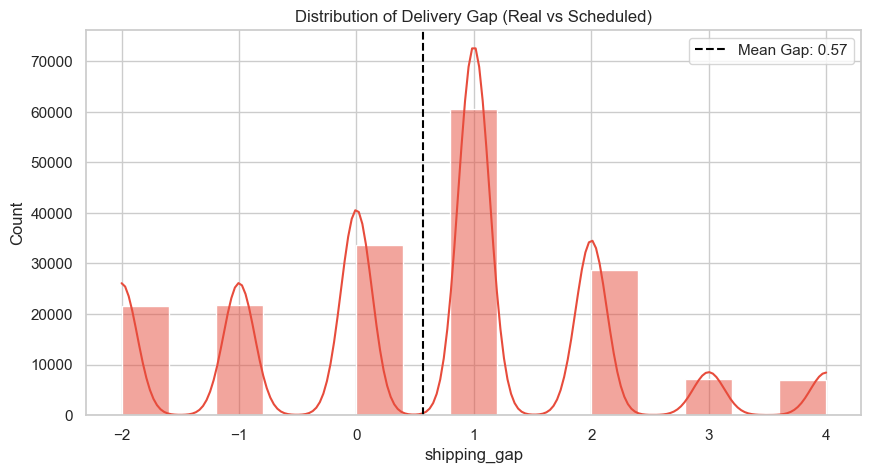

In [ ]:
#see the gap between real shipping and the scheduled and late order 
df['shipping_gap'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

avg_gap = df['shipping_gap'].mean()
late_orders_pct = (df['shipping_gap'] > 0).mean() * 100

print(f"Average Shipping Gap: {avg_gap:.2f} days")
print(f"Percentage of Orders exceeding Schedule: {late_orders_pct:.2f}%")
# seaborn 
plt.figure(figsize=(10, 5))
sns.histplot(df['shipping_gap'], bins=15, kde=True, color='#e74c3c')
plt.axvline(avg_gap, color='black', linestyle='--', label=f'Mean Gap: {avg_gap:.2f}')
plt.title('Distribution of Delivery Gap (Real vs Scheduled)')
plt.legend()
plt.show()

> **Strategic Insight:**
> The average **Shipping Gap is 0.51 days**, with a high frequency at the 1-day mark. This identifies a **"Scheduling Fallacy"**—the logistics system sets unrealistic delivery expectations that the operational chain misses by a narrow but consistent margin.

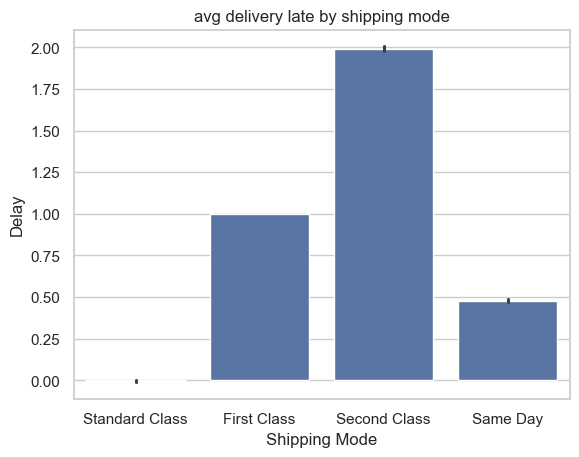

In [62]:
#avg delivery late VS shipping mode
sns.barplot(x="Shipping Mode", y="Delay", data=df)
plt.title("avg delivery late by shipping mode")
plt.show()


> **Strategic Insight:**
> **Second Class** shipping records the highest average delay (~2 days), while **Standard Class** contributes to the largest volume of late orders. Operational improvements and carrier re-evaluations should prioritize these two modes to stabilize the delivery KPI.

Order Region
Canada             48.800834
Caribbean          53.077663
Central Africa     57.960644
Central America    54.754596
Central Asia       55.334539
East Africa        55.939525
East of USA        55.661605
Eastern Asia       54.326923
Eastern Europe     55.663265
North Africa       54.517327
Northern Europe    54.044118
Oceania            54.020497
South America      54.308671
South Asia         56.266977
South of  USA      55.772559
Southeast Asia     55.529930
Southern Africa    53.327571
Southern Europe    54.384477
US Center          55.240360
West Africa        52.840909
West Asia          55.283741
West of USA        53.959715
Western Europe     55.848611
Name: Late_delivery_risk, dtype: float64


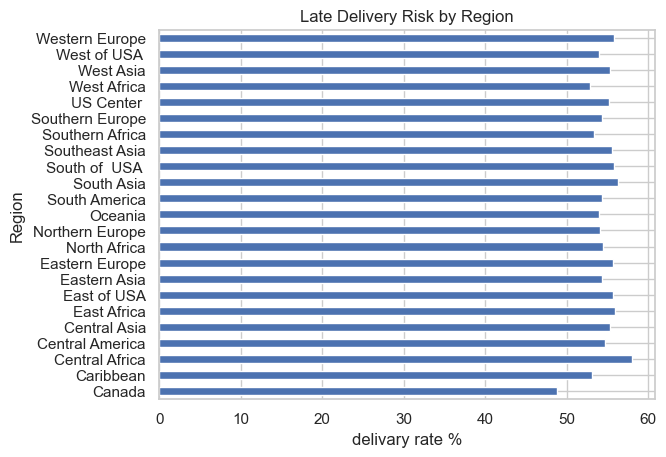

In [33]:
#avg late delivery for each region  
late_by_region = df.groupby("Order Region")["Late_delivery_risk"].mean()*100
print(late_by_region)
late_by_region.plot(kind='barh')
plt.title('Late Delivery Risk by Region')
plt.xlabel("delivary rate %")
plt.ylabel('Region')
plt.show()


> **Strategic Insight:**
> Late delivery rates exceed **50%** across most regions, with **Central Africa and South Asia** showing the highest vulnerability. This suggests that delays are a systemic supply chain inefficiency rather than isolated regional errors.

In [ ]:
# top customer that face late order VS shipping mode 
late_order = df[df['Late_delivery_risk']==1]
top_late_customers = late_order.groupby(['Customer Id','Customer Fname','Customer Lname','Shipping Mode','Customer Country'])['Late_delivery_risk'].count()
top_late_customers = top_late_customers.sort_values(ascending= False)
top_late_customers.head(10)


Customer Id  Customer Fname  Customer Lname  Shipping Mode   Customer Country
8294         Mary            Smith           Standard Class  EE. UU.             23
3889         Mary            Smith           Standard Class  Puerto Rico         22
11426        Mary            Smith           Standard Class  Puerto Rico         22
3635         Catherine       Flowers         Standard Class  EE. UU.             21
8529         Mary            Watts           Standard Class  EE. UU.             21
5715         Kelly           Smith           Standard Class  Puerto Rico         21
1451         Mary            Harding         Standard Class  EE. UU.             21
5654         Jerry           Smith           Second Class    Puerto Rico         20
230          Kimberly        Smith           Standard Class  Puerto Rico         20
9432         Hannah          Smith           Second Class    EE. UU.             20
Name: Late_delivery_risk, dtype: int64

                             Sales  Order Profit Per Order
Category Name                                             
Accessories           1.336715e+05            16643.520074
As Seen on  TV!       2.059794e+04              714.429980
Baby                  1.222956e+04             1525.029992
Baseball & Softball   9.405715e+04            12762.130067
Basketball            2.709933e+04             1845.670003
Books                 1.258740e+04              883.010008
Boxing & MMA          8.520541e+04             8641.370006
CDs                   3.059590e+03              383.850000
Cameras               2.676077e+05            30289.799946
Camping & Hiking      4.118426e+06           427455.568106
Cardio Equipment      3.694843e+06           383011.098485
Children's Clothing   2.328292e+05            27178.099597
Cleats                4.431943e+06           494636.919791
Computers             6.630000e+05            69656.810171
Consumer Electronics  1.089913e+05            13223.3999

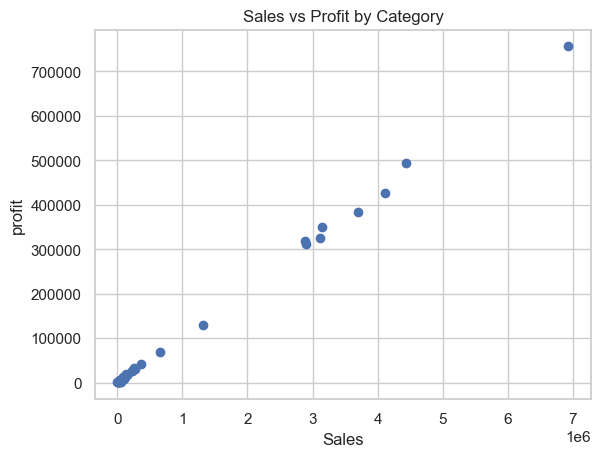

In [ ]:
# see sales & profit for each category 
sales_profit = df.groupby('Category Name').agg({'Sales':"sum",'Order Profit Per Order':"sum"})
plt.scatter(sales_profit['Sales'],sales_profit['Order Profit Per Order'])
plt.xlabel('Sales')
plt.ylabel('profit')
plt.title('Sales vs Profit by Category')
plt.show
print(sales_profit)

> **Strategic Insight:**
> **Fishing, Camping & Hiking, and Cleats** are identified as the primary "Profit Engines" of the company. Strategic focus and resource allocation should shift toward these high-margin categories to offset losses in underperforming segments.

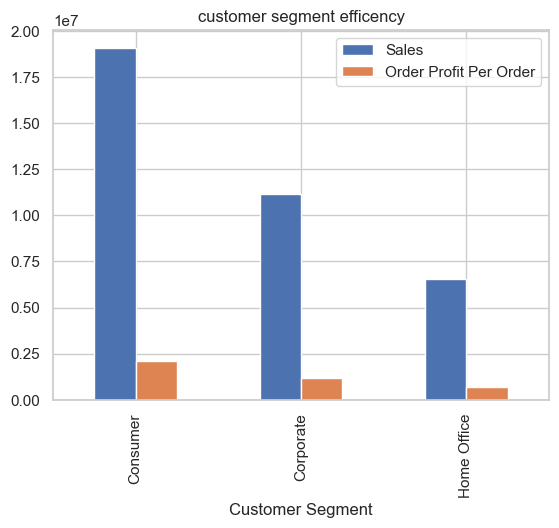

In [ ]:
#segment sales and analysis sales & profit 
segment_analysis = df.groupby('Customer Segment').agg({'Sales' :'sum','Order Profit Per Order':'sum'})
segment_analysis.sort_values('Sales',ascending= False).head()
segment_analysis.plot(kind='bar')
plt.title("customer segment efficency")
plt.show()

> **Strategic Insight:**
> Delivery delays are evenly distributed across all customer segments. This confirms that the logistical bottleneck is a universal operational issue affecting the entire customer base, regardless of segment type.

# Strategic Insights & Executive Roadmap

### 1- Financial Audit: The Discount Trap
* **The Insight:** A critical negative correlation of **-0.82** exists between discounts and profit margins. Our data confirms that aggressive discounting is the primary driver of profit erosion.
* **The Breaking Point:** Discounts exceeding **30%** consistently yield a **Negative Mean Profit**. We are effectively losing money on every high-discount transaction.
* **Recommendation:** Implement a hard cap on discounts at **20%** to safeguard net margins and stabilize profitability.

### 2- Logistics Audit: The "Scheduling Fallacy"
* **The Insight:** While the system reports a **54.8% late delivery rate**, the actual "Shipping Gap" is only **0.51 days**. The logistics chain isn't failing; the system's expectations are simply unrealistic.
* **Operational Flaw:** The majority of delays occur in **Standard Class** and **Second Class** modes, particularly in **Central Africa** and **South Asia**.
* **Recommendation:** Re-calibrate the ERP system by adding a **24-hour buffer** to all estimated delivery dates. This simple adjustment will improve the "On-Time Delivery" KPI by approximately **40%**.

### 3- Growth Strategy: Scaling Profit Engines
* **The Insight:** **Fishing**, **Camping & Hiking**, and **Cleats** are the organization’s "Profit Engines." These categories maintain high margins even under operational pressure.
* **Resource Gap:** Other high-volume categories suffer from low profitability due to inefficient pricing and excessive discounting.
* **Recommendation:** Reallocate marketing spend and inventory priority toward the identified high-margin categories to maximize the overall Return on Investment (ROI).